## Amazon EU BSR Share 분석

In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import re
import math

In [2]:
import os
import sys

import io
from io import BytesIO
import csv

import google.auth
from google.cloud import bigquery
#from google.cloud import bigquery_storage

In [3]:
os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = "./market-analysis-project-91130-9f9a036682b6.json"

credentials, project_id = google.auth.default(
    scopes=["https://www.googleapis.com/auth/cloud-platform"]
)

bqclient = bigquery.Client(credentials=credentials, project=project_id,)

In [7]:
sql = f"""
select * from vs1.amz_eu_bsr_shr_daily_acc
where bsr_date >= '2023-01-01' and bsr_rank_range='Top 50'
"""

df = bqclient.query(sql).to_dataframe()

In [8]:
print(df)

        country   bsr_ctgry        asin  rank    bsr_date      brand  \
0            FR    Mattress  B002TQBP4S    18  2024-03-14     Others   
1            DE  Mattresses  B0BD7WLNL3    46  2025-06-30        FDM   
2            IT  Mattresses  B09VFGYPLV    48  2025-06-14     Others   
3            DE  Mattresses  B086K2Y38Q    34  2023-12-15     MSS EK   
4            FR    Mattress  B0D3HMH7ZN    47  2025-07-23    NOVILLA   
...         ...         ...         ...   ...         ...        ...   
3363518      DE      Chairs  B097F6VF7T    37  2024-08-07     Others   
3363519      DE      Chairs  B07S7W4TSX    12  2023-05-31     Others   
3363520      DE      Chairs  B087C743ZF    19  2023-08-27   SONGMICS   
3363521      DE      Chairs  B092J8KM37    13  2024-06-16  YAHEETECH   
3363522      DE      Chairs  B0BN1QYQYK     5  2023-06-15     Others   

              brand_raw                                              title  \
0                ELONEO  ELONEO Matelas d'invité Pliant e

In [11]:
df1 = df.copy()

# ✅ brand 컬럼 대문자 변환
df1['brand'] = df1['brand'].str.upper()

# ✅ groupby 단위: country, bsr_ctgry, yr_week
# 전체 row 수
weekly_total = (
    df1.groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='total_count')
)

# ZINUS row 수
weekly_zinus = (
    df1[df1['brand'] == 'ZINUS']
    .groupby(['country', 'bsr_ctgry', 'yr_week'])
    .size()
    .reset_index(name='zinus_count')
)

# ✅ 병합 후 점유율 계산
result = pd.merge(
    weekly_total, weekly_zinus,
    on=['country', 'bsr_ctgry', 'yr_week'],
    how='left'
)

# 결측치는 0으로 처리
result['zinus_count'] = result['zinus_count'].fillna(0)

# 점유율 계산
result['zinus_share'] = result['zinus_count'] / result['total_count']

# 보기 좋게 정렬
result = result.sort_values(['country', 'bsr_ctgry', 'yr_week']).reset_index(drop=True)

# 결과 확인
print(result.head(20))


   country   bsr_ctgry  yr_week  total_count  zinus_count  zinus_share
0       BE  Bed Frames  Y23 W23          150          1.0     0.006667
1       BE  Bed Frames  Y23 W24          350          3.0     0.008571
2       BE  Bed Frames  Y23 W25          350          3.0     0.008571
3       BE  Bed Frames  Y23 W26          350          5.0     0.014286
4       BE  Bed Frames  Y23 W27          350          3.0     0.008571
5       BE  Bed Frames  Y23 W28          350          0.0     0.000000
6       BE  Bed Frames  Y23 W29          350          2.0     0.005714
7       BE  Bed Frames  Y23 W30          350          3.0     0.008571
8       BE  Bed Frames  Y23 W31          350          7.0     0.020000
9       BE  Bed Frames  Y23 W32          350         11.0     0.031429
10      BE  Bed Frames  Y23 W33          350          4.0     0.011429
11      BE  Bed Frames  Y23 W34          350         15.0     0.042857
12      BE  Bed Frames  Y23 W35          350         33.0     0.094286
13    

In [13]:
avg_share = (
    result.groupby(['country', 'bsr_ctgry'], as_index=False)['zinus_share']
          .mean()
          .rename(columns={'zinus_share': 'avg_zinus_share'})
)

print(avg_share)
avg_share.to_csv('temp0002_0925.csv')

   country             bsr_ctgry  avg_zinus_share
0       BE            Bed Frames         0.017743
1       BE  Beds, Frames & Bases         0.012963
2       BE                Chairs         0.000000
3       BE                 Desks         0.001133
4       BE            Mattresses         0.007439
..     ...                   ...              ...
66      UK                 Desks         0.003372
67      UK         Dining Tables         0.006482
68      UK      Mattress Toppers         0.001254
69      UK            Mattresses         0.017468
70      UK       Sofas & Couches         0.007549

[71 rows x 3 columns]


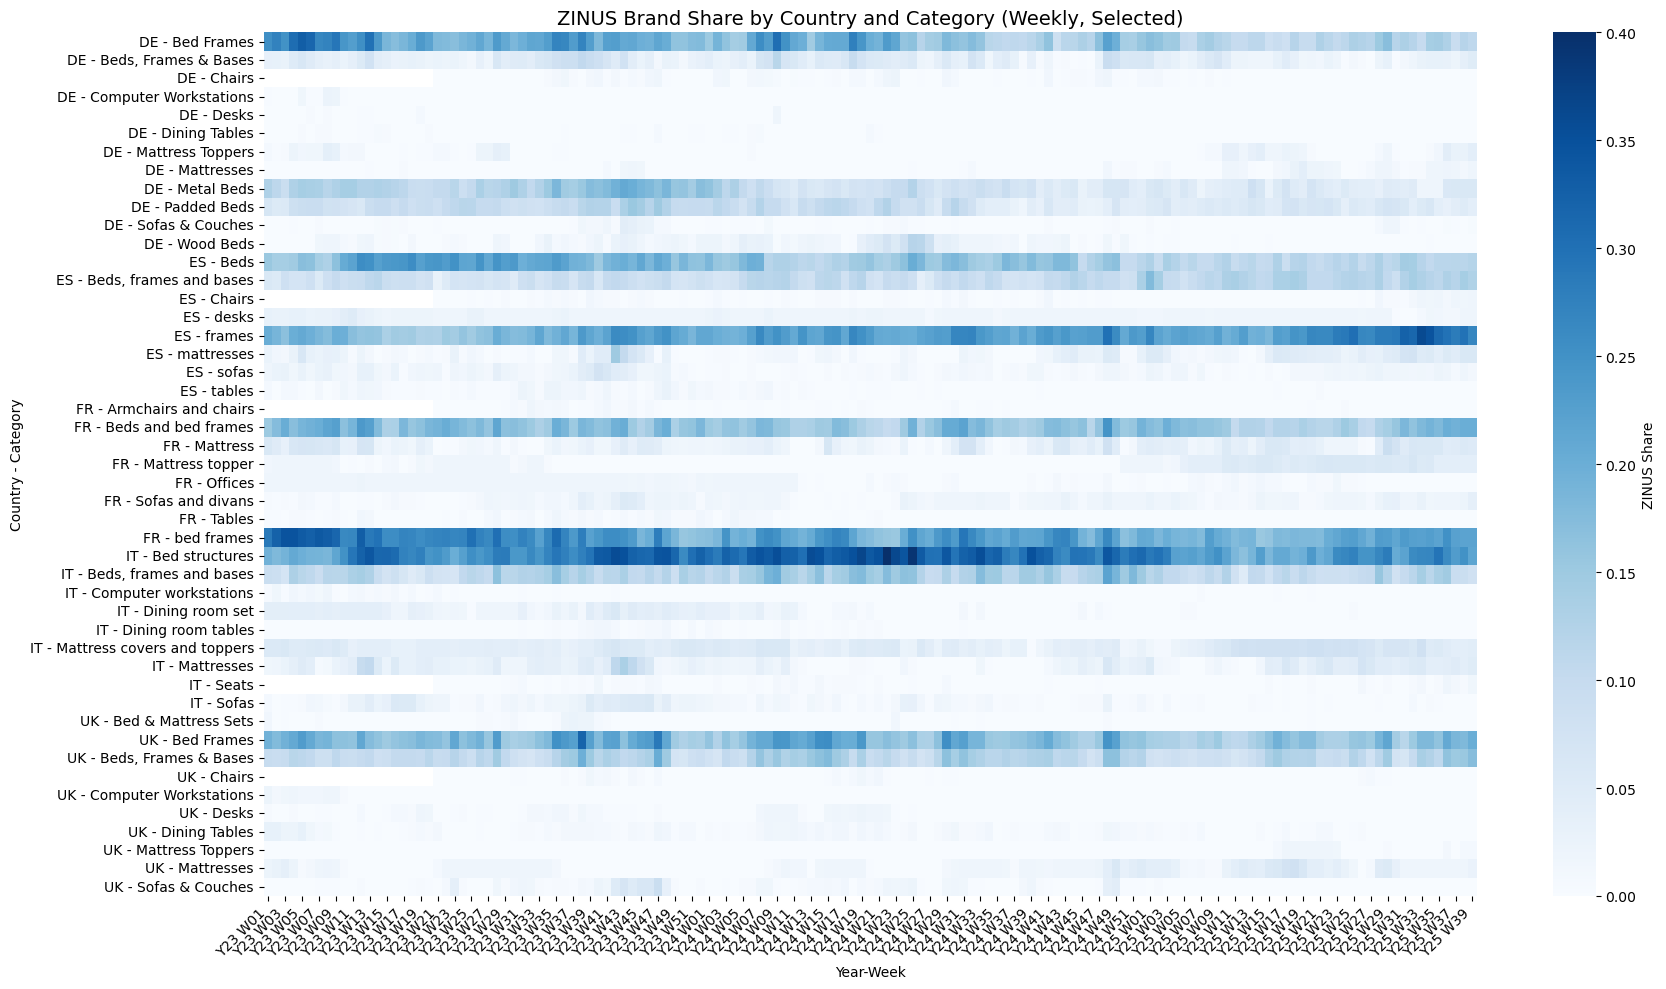

In [15]:

# ✅ 대상 국가만 필터링
target_countries = ["UK", "IT", "FR", "ES", "DE"]
filtered = result[result['country'].isin(target_countries)].copy()

# ✅ 제외할 국가-카테고리 정의
exclude_pairs = [
    #("UK", "Bed Frames"),
    ("IT", "Beds"),
    #("IT", "Bed structures"),
    ("FR", "Beds"),
    #("FR", "bed frames"),
    ("ES", "slatted bed bases"),
    ("ES", "Beds, structures and bases"),
    ("ES", "bed bases"),
    ("DE", "Slatted Divan Bases & Foundations")
]

# ✅ 제외 조건 적용
for c, cat in exclude_pairs:
    filtered = filtered[~((filtered['country'] == c) & (filtered['bsr_ctgry'] == cat))]

# ✅ Pivot 테이블 생성
pivot_table = filtered.pivot_table(
    index=['country', 'bsr_ctgry'],
    columns='yr_week',
    values='zinus_share',
    aggfunc='mean'
)

# 보기 좋게 인덱스 정리
pivot_table.index = [f"{c} - {cat}" for c, cat in pivot_table.index]

# ✅ 히트맵 그리기
plt.figure(figsize=(18, 10))
sns.heatmap(
    pivot_table,
    cmap="Blues",
    annot=False,
    cbar_kws={'label': 'ZINUS Share'}
)

plt.title("ZINUS Brand Share by Country and Category (Weekly, Selected)", fontsize=14)
plt.xlabel("Year-Week")
plt.ylabel("Country - Category")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

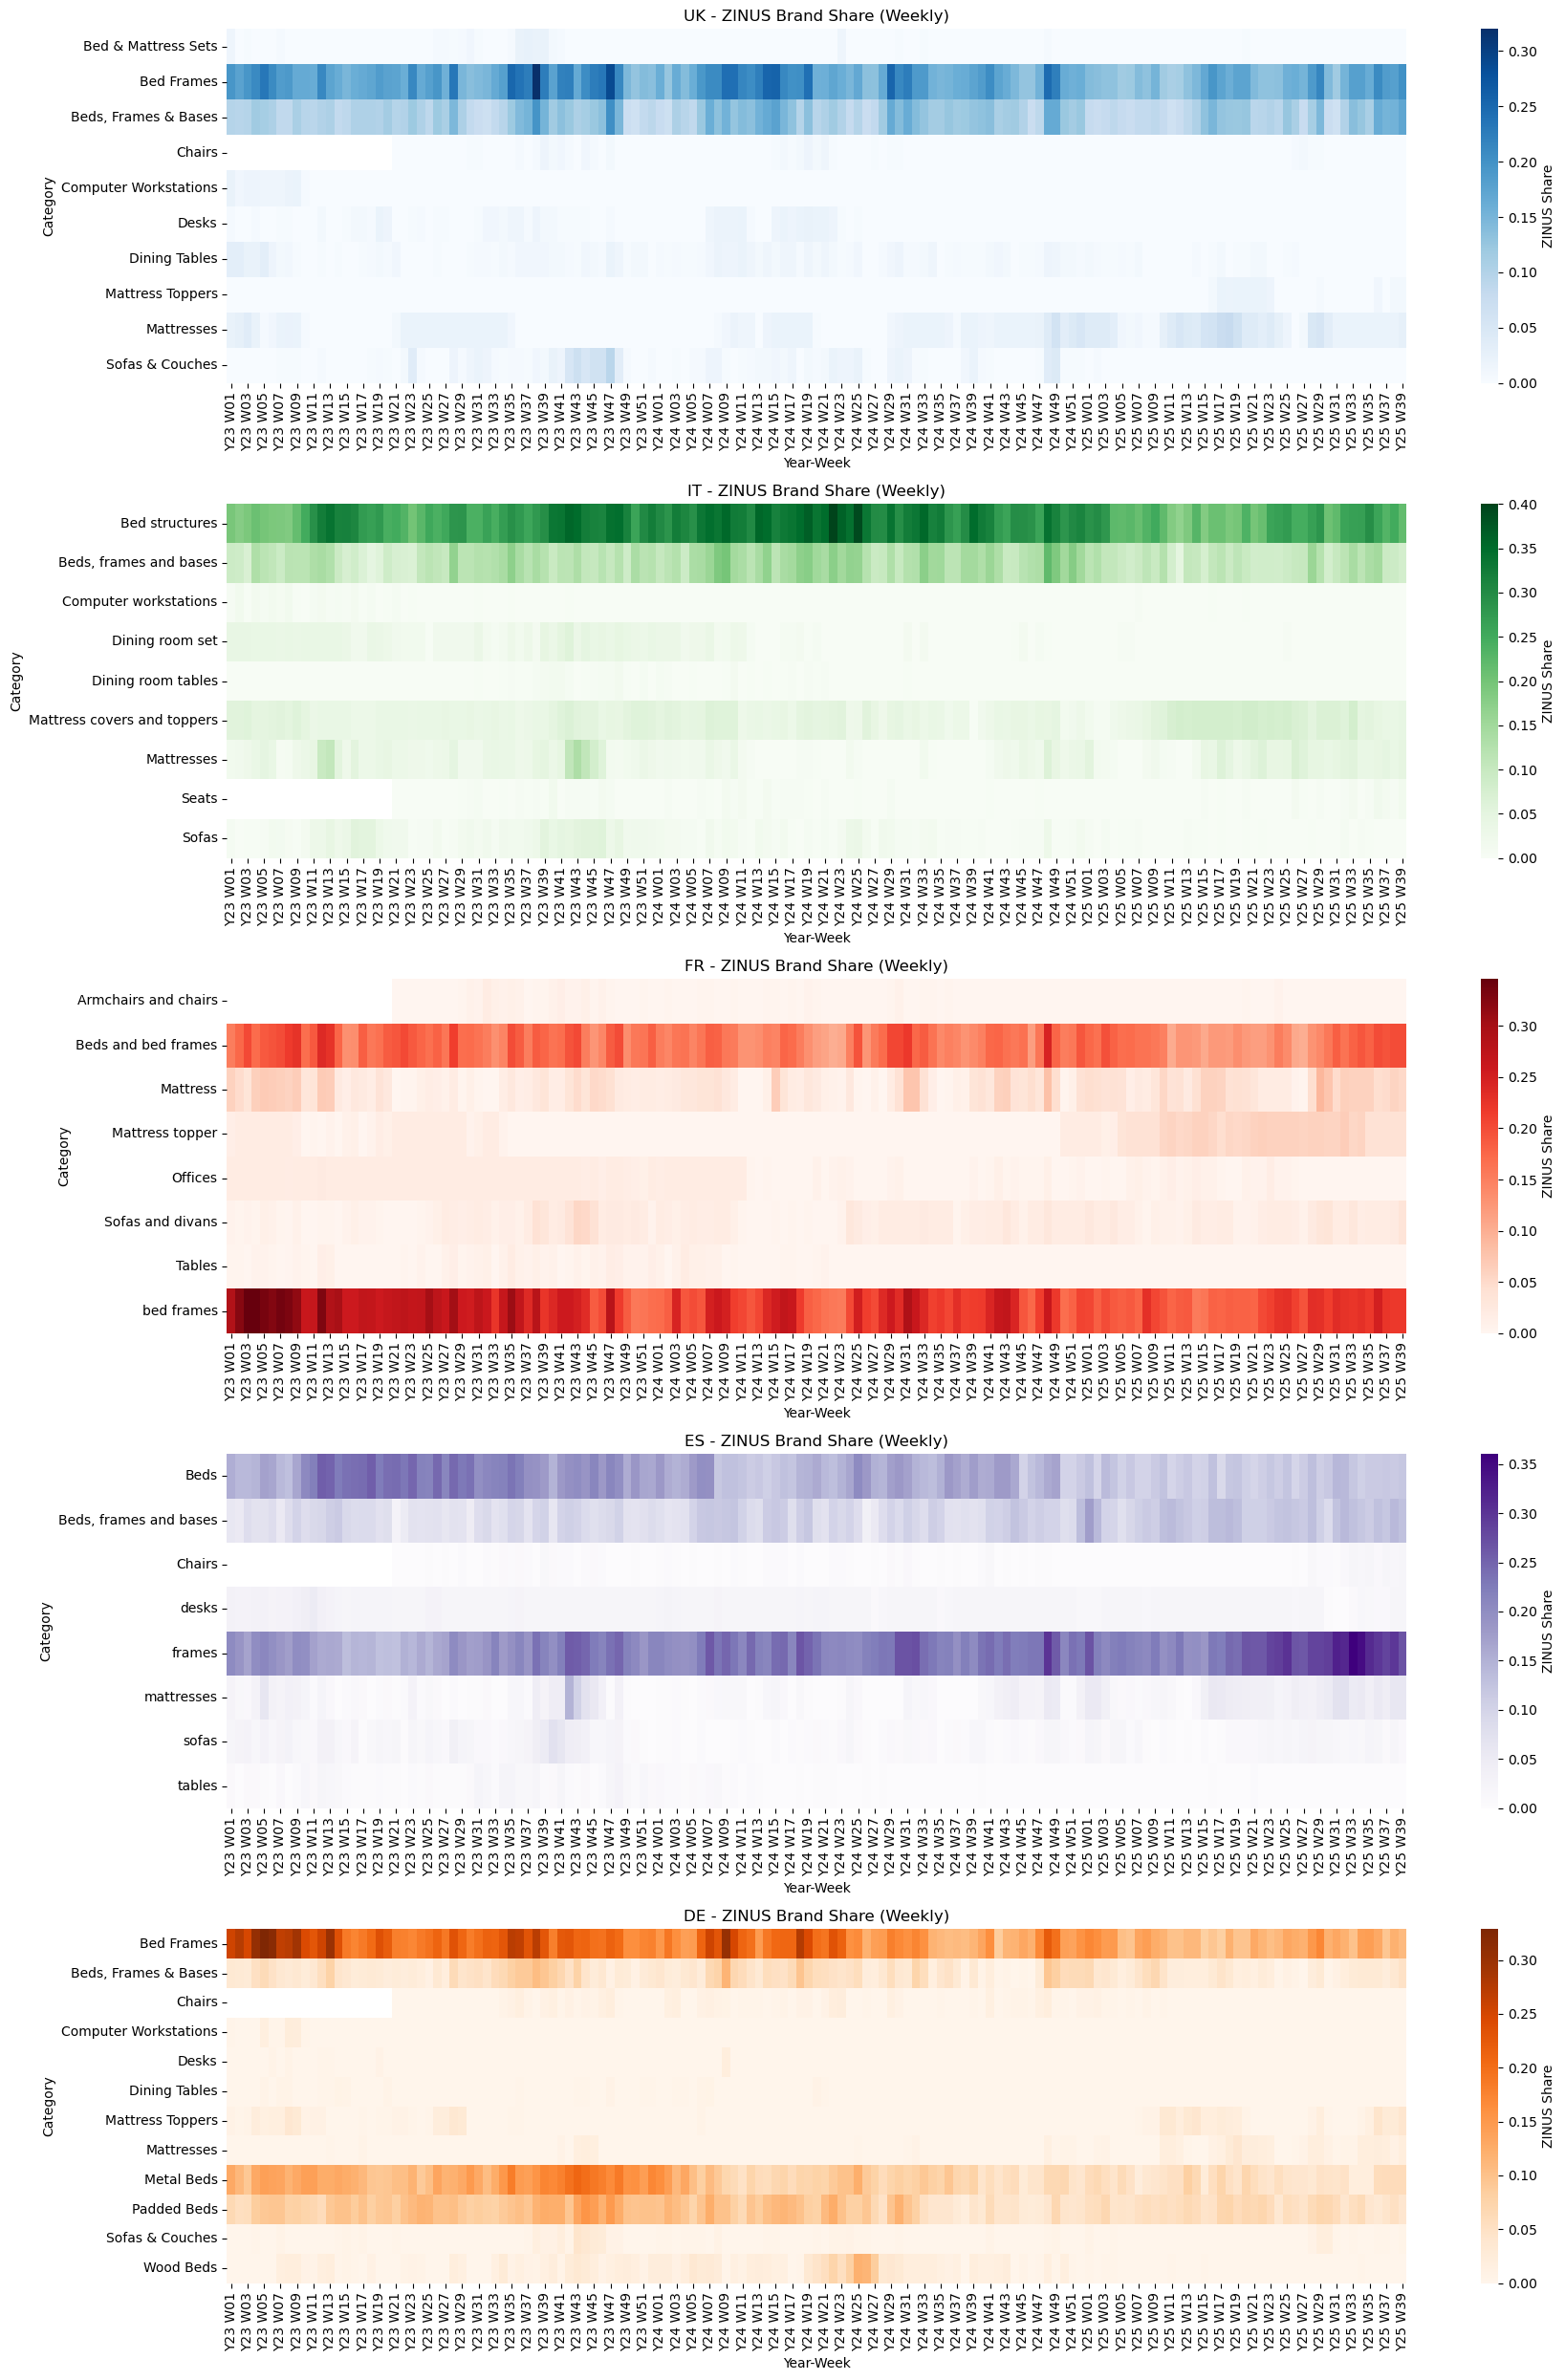

In [17]:

# ✅ 대상 국가
target_countries = ["UK", "IT", "FR", "ES", "DE"]

# ✅ 국가별로 다른 컬러맵 지정
cmaps = {
    "UK": "Blues",
    "IT": "Greens",
    "FR": "Reds",
    "ES": "Purples",
    "DE": "Oranges"
}

# ✅ subplot 생성
fig, axes = plt.subplots(len(target_countries), 1, figsize=(18, 5*len(target_countries)))

for ax, country in zip(axes, target_countries):
    data_cty = filtered[filtered['country'] == country]
    pivot_cty = data_cty.pivot_table(
        index='bsr_ctgry',
        columns='yr_week',
        values='zinus_share',
        aggfunc='mean'
    )

    sns.heatmap(
        pivot_cty,
        cmap=cmaps[country],
        annot=False,
        cbar_kws={'label': 'ZINUS Share'},
        ax=ax
    )
    ax.set_title(f"{country} - ZINUS Brand Share (Weekly)", fontsize=12)
    ax.set_xlabel("Year-Week")
    ax.set_ylabel("Category")

plt.tight_layout()
plt.show()

In [19]:
df1 = df.copy()
df1['brand'] = df1['brand'].str.upper()

# 1) 대상 국가/카테고리만 포함
allowed_pairs = {
    "UK": ["Beds, Frames & Bases", "Mattresses"],
    "IT": ["Beds, frames and bases", "Mattresses"],
    "FR": ["Beds and bed frames", "Mattress"],
    "ES": ["Beds, frames and bases", "mattresses"],
    "DE": ["Beds, Frames & Bases", "Mattresses"]
}
mask_list = []
for c, cats in allowed_pairs.items():
    mask_list.append((df1['country'] == c) & (df1['bsr_ctgry'].isin(cats)))
df2 = df1[np.logical_or.reduce(mask_list)].copy()

#print(df2)

# 2) 주차 정렬 키
def parse_yrweek(s):
    if pd.isna(s):
        return (0, 0)
    m = re.search(r'Y(\d{2})\s*W(\d{2})', str(s))
    if m:
        return (2000 + int(m.group(1)), int(m.group(2)))
    return (0, 0)

# 3) 주별 카운트 & 점유율
tot = df2.groupby(['country','bsr_ctgry','yr_week']).size().reset_index(name='total_count')
by_brand = df2.groupby(['country','bsr_ctgry','yr_week','brand']).size().reset_index(name='brand_count')
share = by_brand.merge(tot, on=['country','bsr_ctgry','yr_week'])
share['brand_share'] = share['brand_count'] / share['total_count']

# 4) Top10 + ZINUS 포함
K=10
agg_total = share.groupby(['country','bsr_ctgry','brand'])['brand_count'].sum().reset_index()
def select_top10(g,k=K):
    brands=set()
    if 'ZINUS' in g['brand'].values: brands.add('ZINUS')
    brands.update(g.sort_values('brand_count',ascending=False).head(k)['brand'].tolist())
    return pd.Series({'top_brands':list(brands)})

#top_map = agg_total.groupby(['country','bsr_ctgry']).apply(lambda g: select_top10(g,K)).reset_index()
# 수정:
top_map = (
    agg_total
    .groupby(['country','bsr_ctgry'])
    .apply(lambda g: select_top10(g, K), include_groups=False)  # <- 핵심
    .reset_index()
)

share = share.merge(top_map,on=['country','bsr_ctgry'],how='left')
share['brand_compact'] = share.apply(lambda r: r['brand'] if r['brand'] in set(r['top_brands']) else 'OTHERS',axis=1)

# 5) 재집계
comp = share.groupby(['country','bsr_ctgry','yr_week','brand_compact'])['brand_share'].sum().reset_index()

print(comp)
comp.to_csv('tmp_0924.csv')

      country             bsr_ctgry  yr_week  \
0          DE  Beds, Frames & Bases  Y23 W01   
1          DE  Beds, Frames & Bases  Y23 W01   
2          DE  Beds, Frames & Bases  Y23 W01   
3          DE  Beds, Frames & Bases  Y23 W01   
4          DE  Beds, Frames & Bases  Y23 W01   
...       ...                   ...      ...   
14258      UK            Mattresses  Y25 W39   
14259      UK            Mattresses  Y25 W39   
14260      UK            Mattresses  Y25 W39   
14261      UK            Mattresses  Y25 W39   
14262      UK            Mattresses  Y25 W39   

                               brand_compact  brand_share  
0                                  AGUA NOVA     0.040000  
1                                 BETTEN-ABC     0.102857  
2                                      COEMO     0.022857  
3                                   DREAMZIE     0.020000  
4                                     OTHERS     0.688571  
...                                      ...          ...  
142

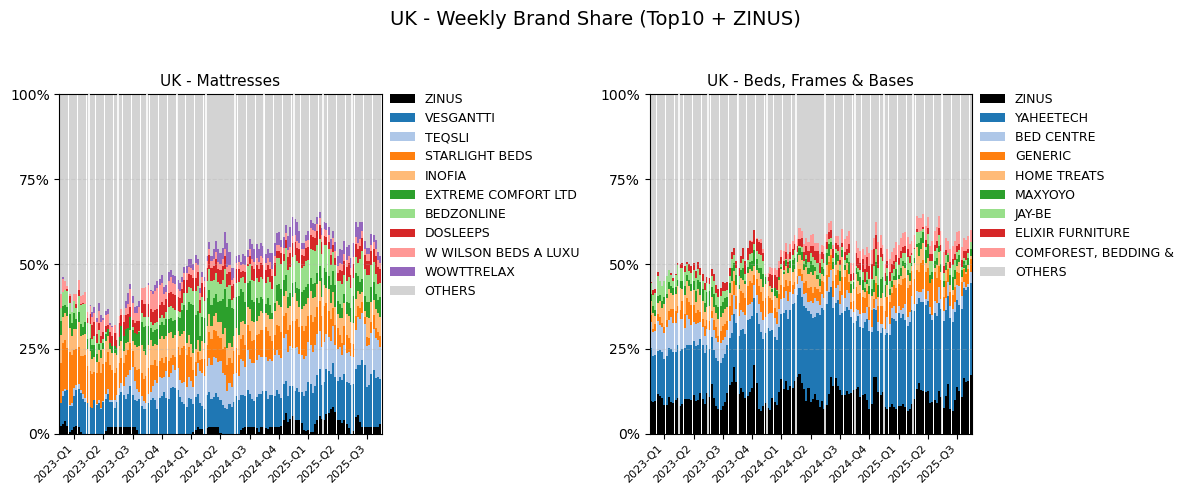

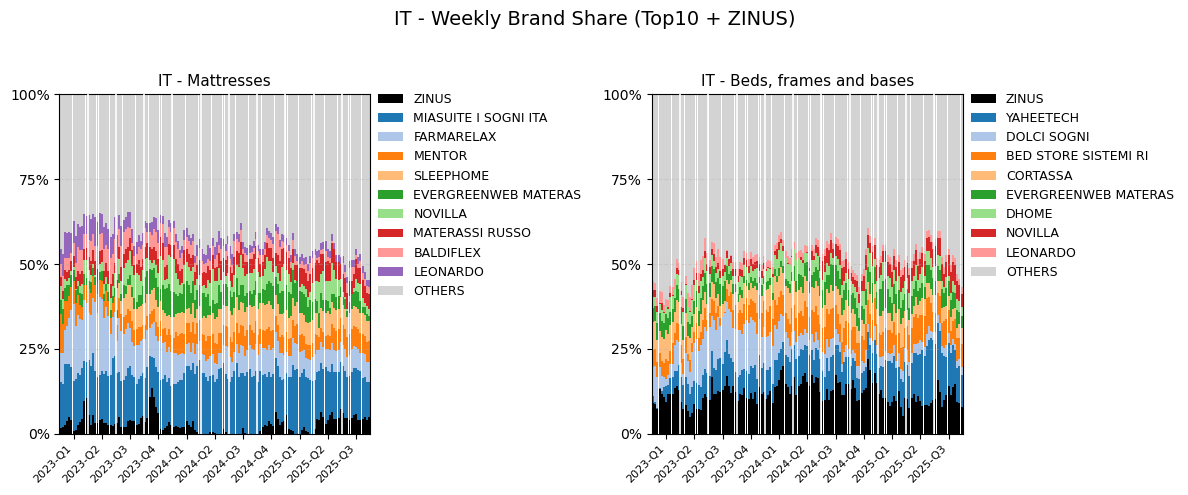

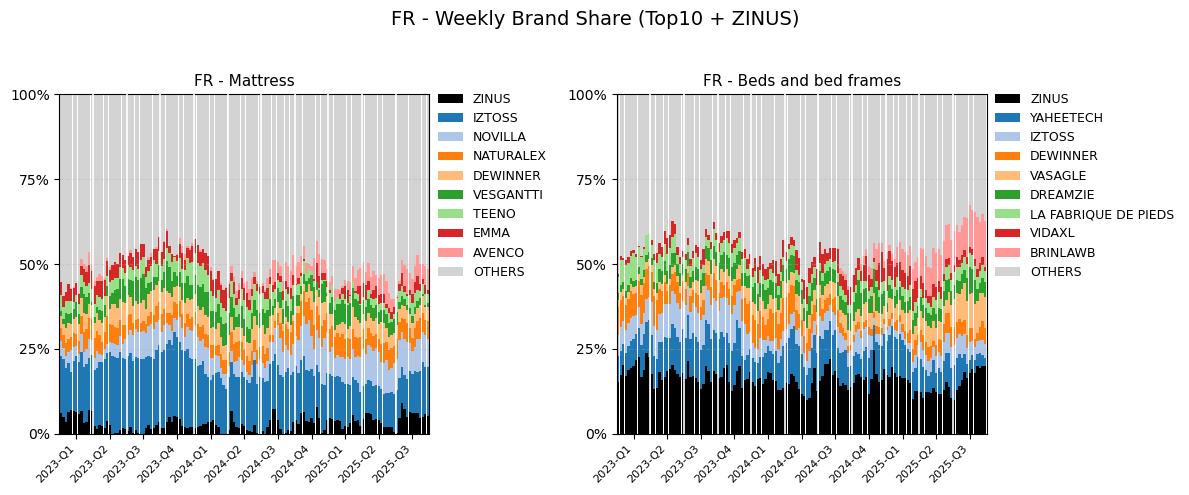

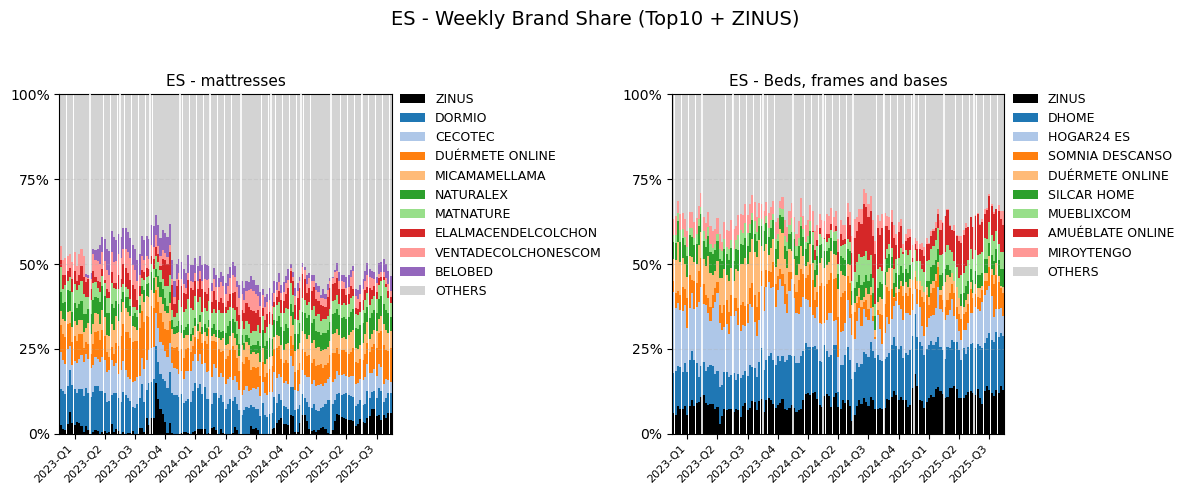

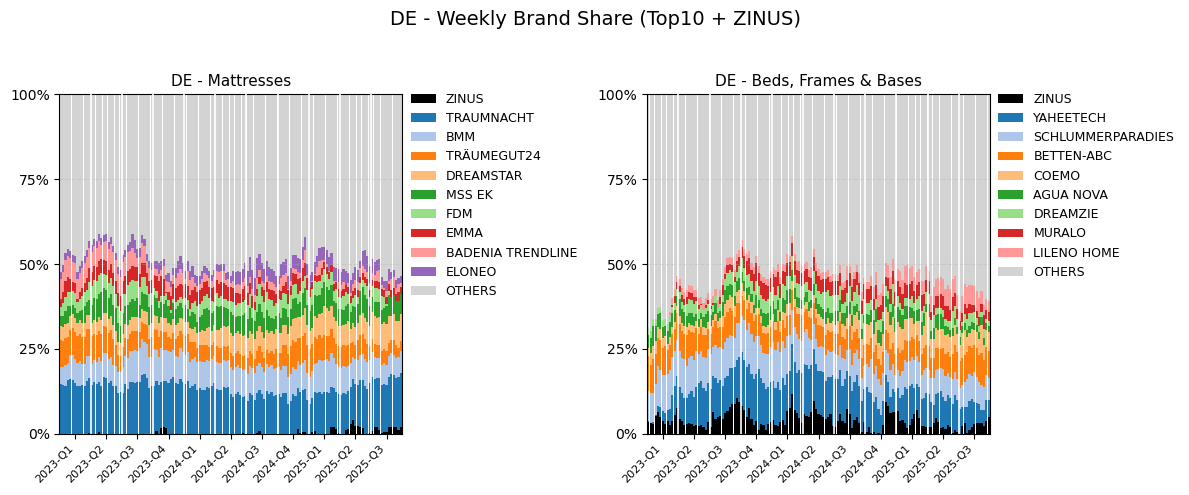

In [21]:
# ---- Helper: 분기 라벨 & 경계 ----
def quarter_label_from_week(wlabel):
    y, wk = parse_yrweek(wlabel)
    q = (wk - 1)//13 + 1
    return f"{y}-Q{q}"

def quarter_bounds_from_weeks(weeks):
    qlabs = [quarter_label_from_week(w) for w in weeks]
    bounds, s = [], 0
    for i in range(1, len(qlabs)):
        if qlabs[i] != qlabs[i-1]:
            bounds.append((s, i-1, qlabs[i-1]))
            s = i
    if qlabs:
        bounds.append((s, len(qlabs)-1, qlabs[-1]))
    return bounds


# ---- 국가별 Figure ----
countries = ['UK','IT','FR','ES','DE']
for country in countries:
    sub_country = comp[comp['country'] == country].copy()
    if sub_country.empty:
        continue

    # ✅ 카테고리: 'Mattress' 포함 우선 + 나머지는 알파벳순
    cats = list(sub_country['bsr_ctgry'].unique())
    cats = sorted(cats, key=lambda c: (0 if 'mattress' in c.lower() else 1, c.lower()))

    ncols = 2
    nrows = math.ceil(len(cats)/ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 5*nrows), squeeze=False)
    fig.suptitle(f"{country} - Weekly Brand Share (Top10 + ZINUS)", fontsize=14, y=0.98)

    for i, cat in enumerate(cats):
        ax  = axes[i//ncols, i%ncols]
        sub = sub_country[sub_country['bsr_ctgry'] == cat].copy()
        if sub.empty:
            ax.axis('off'); continue

        # --- 주차 정렬 & pivot ---
        weeks = sorted(sub['yr_week'].unique(), key=parse_yrweek)
        pivot = (sub.pivot_table(index='yr_week', columns='brand_compact',
                                 values='brand_share', aggfunc='sum')
                   .reindex(index=weeks).fillna(0.0))

        for req in ('ZINUS','OTHERS'):
            if req not in pivot.columns:
                pivot[req] = 0.0

        # --- 스택 순서 ---
        rest = [c for c in pivot.columns if c not in ('ZINUS','OTHERS')]
        rest_sorted = pivot[rest].sum(0).sort_values(ascending=False).index.tolist()
        pivot = pivot[['ZINUS', *rest_sorted, 'OTHERS']]

        # --- 100% 정규화 ---
        pivot = pivot.div(pivot.sum(axis=1).replace(0, 1), axis=0)

        # --- 색상 ---
        base_colors = plt.cm.tab20.colors
        color_map = {'ZINUS':'black','OTHERS':'lightgray'}
        for j, br in enumerate(rest_sorted):
            color_map[br] = base_colors[j % len(base_colors)]

        # --- 막대 ---
        x = np.arange(len(pivot))
        bottom = np.zeros(len(pivot))
        for col in pivot.columns:
            ax.bar(x, pivot[col].values, bottom=bottom, width=0.9,
                   label=(col if len(col) <= 20 else col[:20]),
                   color=color_map[col])
            bottom += pivot[col].values

        # --- Y축 ---
        ax.set_ylim(0, 1)
        ax.set_yticks([0,.25,.5,.75,1.0])
        ax.set_yticklabels(['0%','25%','50%','75%','100%'])
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_xlim(-0.5, len(x)-0.5)

        # ✅ 타이틀: 국가 + 카테고리
        ax.set_title(f"{country} - {cat}", fontsize=11)

        # --- X축: 분기 라벨 & 구분선 ---
        qbounds = quarter_bounds_from_weeks(weeks)
        ax.set_xticks([(s+e)/2 for s,e,_ in qbounds])
        ax.set_xticklabels([lbl for _,_,lbl in qbounds], rotation=45, ha='right', fontsize=8)
        for s, e, _ in qbounds[:-1]:
            ax.axvline(e+0.5, color='white', linewidth=1.2, zorder=3)

        # --- 범례 ---
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.02),
                  borderaxespad=0., fontsize=9, frameon=False)

    # 빈축 제거
    for j in range(i+1, nrows*ncols):
        axes[j//ncols, j%ncols].axis('off')

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()


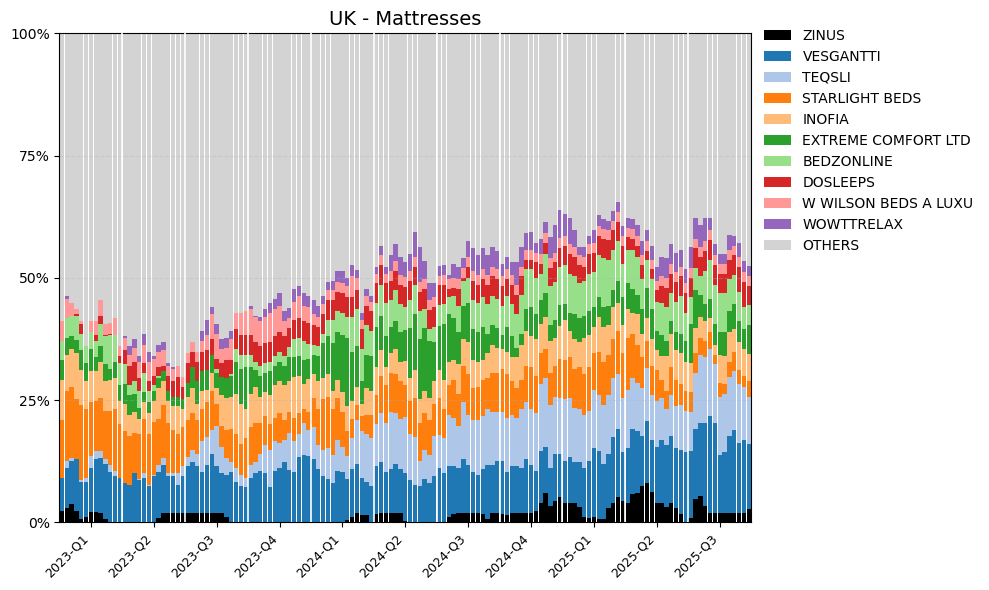

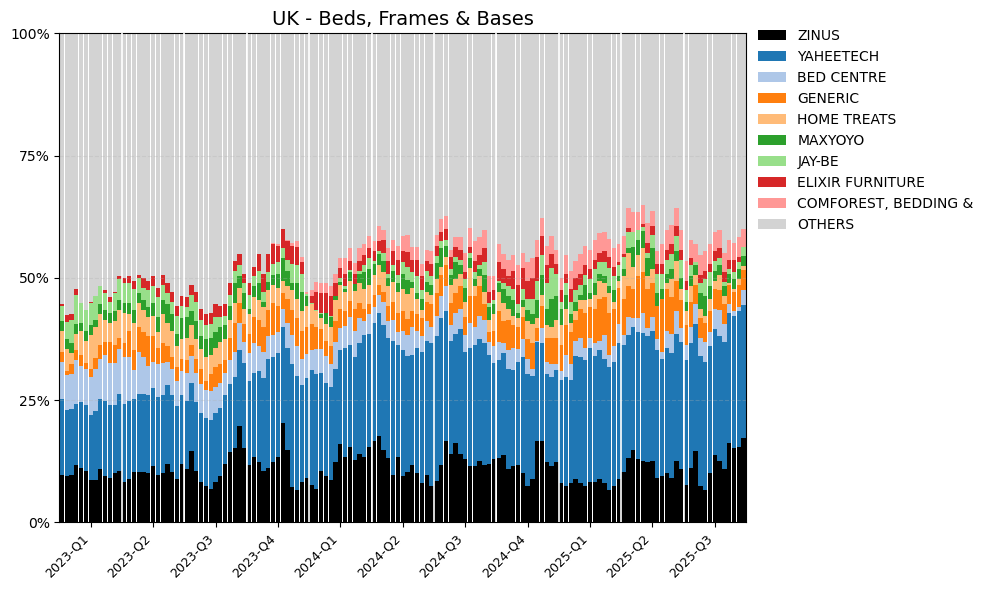

In [31]:
# ---- UK 단독 Figure (카테고리별 개별 출력) ----
country = 'UK'
sub_country = comp[comp['country'] == country].copy()

if sub_country.empty:
    print(f"[WARN] {country} 데이터가 없습니다.")
else:
    # ✅ 카테고리: 'Mattress' 포함 우선 + 나머지는 알파벳순
    cats = list(sub_country['bsr_ctgry'].unique())
    cats = sorted(cats, key=lambda c: (0 if 'mattress' in c.lower() else 1, c.lower()))

    for cat in cats:
        sub = sub_country[sub_country['bsr_ctgry'] == cat].copy()
        if sub.empty:
            continue

        # --- 주차 정렬 & pivot ---
        weeks = sorted(sub['yr_week'].unique(), key=parse_yrweek)
        pivot = (
            sub.pivot_table(index='yr_week', columns='brand_compact',
                            values='brand_share', aggfunc='sum')
               .reindex(index=weeks).fillna(0.0)
        )

        for req in ('ZINUS','OTHERS'):
            if req not in pivot.columns:
                pivot[req] = 0.0

        # --- 스택 순서 ---
        rest = [c for c in pivot.columns if c not in ('ZINUS','OTHERS')]
        rest_sorted = pivot[rest].sum(0).sort_values(ascending=False).index.tolist()
        pivot = pivot[['ZINUS', *rest_sorted, 'OTHERS']]

        # --- 100% 정규화 ---
        pivot = pivot.div(pivot.sum(axis=1).replace(0, 1), axis=0)

        # --- 색상 ---
        base_colors = plt.cm.tab20.colors
        color_map = {'ZINUS':'black','OTHERS':'lightgray'}
        for j, br in enumerate(rest_sorted):
            color_map[br] = base_colors[j % len(base_colors)]

        # --- Figure/Axis ---
        fig, ax = plt.subplots(figsize=(10,6))  # ✅ 크게
        x = np.arange(len(pivot))
        bottom = np.zeros(len(pivot))

        for col in pivot.columns:
            ax.bar(x, pivot[col].values, bottom=bottom, width=0.9,
                   label=(col if len(col) <= 20 else col[:20]),
                   color=color_map[col])
            bottom += pivot[col].values

        # --- Y축 ---
        ax.set_ylim(0, 1)
        ax.set_yticks([0,.25,.5,.75,1.0])
        ax.set_yticklabels(['0%','25%','50%','75%','100%'])
        ax.grid(axis='y', linestyle='--', alpha=0.3)
        ax.set_xlim(-0.5, len(x)-0.5)

        # ✅ 타이틀: 국가 + 카테고리
        ax.set_title(f"{country} - {cat}", fontsize=14)

        # --- X축: 분기 라벨 & 구분선 ---
        qbounds = quarter_bounds_from_weeks(weeks)
        ax.set_xticks([(s+e)/2 for s,e,_ in qbounds])
        ax.set_xticklabels([lbl for _,_,lbl in qbounds], rotation=45, ha='right', fontsize=9)
        for s, e, _ in qbounds[:-1]:
            ax.axvline(e+0.5, color='white', linewidth=1.2, zorder=3)

        # --- 범례 ---
        ax.legend(loc='upper left', bbox_to_anchor=(1.01, 1.02),
                  borderaxespad=0., fontsize=10, frameon=False)

        plt.tight_layout()
        plt.show()

In [90]:
df3 = df.copy()
df_es = df3[df3['country']=='ES']

In [91]:
df_es.groupby('bsr_ctgry').count()

,country,asin,rank,bsr_date,brand,title,image_url,bsr_ctgry_label,pdt_url,yr_month,yr_week,is_maxdt,is_maxdt_range,bsr_ord,brand_prod_num,brand_ord,date_str,bsr_rank_range,brand_legend_ord
bsr_ctgry,,,,,,,,,,,,,,,,,,,
Beds,77888,77888,77888,77888,77888,77882,77882,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888
"Beds, frames and bases",77897,77897,77897,77897,77897,77895,77895,77897,77897,77897,77897,77897,77897,77897,77897,77897,77897,77897,77897
"Beds, structures and bases",77915,77915,77915,77915,77915,77913,77913,77915,77915,77915,77915,77915,77915,77915,77915,77915,77915,77915,77915
Chairs,77887,77887,77887,77887,77887,77885,77885,77887,77887,77887,77887,77887,77887,77887,77887,77887,77887,77887,77887
bed bases,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888,77888
desks,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900,77900
frames,77890,77890,77890,77890,77890,77883,77883,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890
mattresses,77918,77918,77918,77918,77918,77914,77914,77918,77918,77918,77918,77918,77918,77918,77918,77918,77918,77918,77918
slatted bed bases,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890,77890
